In [3]:
from pilotpy.tools import *
import scanpy as sc
#from pilot_gm_vae import *

In [10]:
def trajectory(adata, n_evecs=2, epsilon=1, alpha=0.5, knn=64, sample_col=1, 
               clusters='status', label_act=False, colors=['#377eb8', '#ff7f00', '#e41a1c'],
               legend_order=None, legend_outside=False, location_labels='center', 
               figsize=(12,12), font_size=24, axes_line_width=1, axes_color='black',
               facecolor='white', point_size=100, cmap='viridis', fontsize_legend=24,
               alpha_trans=1, plot_title="Trajectory of the disease progression"):
    
    """
    Find trajectories using Diffusion Maps and visualize the trajectory plot.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix containing EMD, annotations, and other necessary data.
    n_evecs : int, optional
        Number of embedding vectors, by default 2.
    epsilon : float or str, optional
        Method for choosing the epsilon in diffusion maps, by default 1.
    alpha : float, optional
        Normalization parameter in the bandwidth function, by default 0.5.
    knn : int, optional
        Number of nearest neighbors for constructing the kernel, by default 64.
    sample_col : int, optional
        Index of the column representing sample IDs in annotation data, by default 1.
    clusters : str, optional
        Name of the column representing clusters/categories in annotation data, by default 'status'.
    label_act : bool, optional
        Whether to label data points with sample IDs, by default False.
    colors : list, optional
        List of colors for different categories, by default ['#377eb8', '#ff7f00', '#e41a1c'].
    legend_order : list, optional
        List specifying the order of categories in legend, by default None.
    legend_outside : bool, optional
        Whether to place legend outside the plot, by default False.
    location_labels : str, optional
        Location of the legend labels when inside plot, by default 'center'.
    figsize : tuple, optional
        figsize, by default (12,12).
    font_size : int, optional
        Font size for labels and annotations, by default 24.
    axes_line_width : float, optional
        Line width of the axes, by default 1.
    axes_color : str, optional
        Color of the axes lines, by default 'black'.
    facecolor : str, optional
        Background color of the figure, by default 'white'.
    point_size : int, optional
        Size of the data points in the plot, by default 100.
    cmap : str, optional
        Colormap for scatter plot, by default 'viridis'.
    fontsize_legend : int, optional
        Font size of the legend, by default 24.
    alpha_trans : float, optional
        Transparency level for data points, by default 1.
    plot_title : str, optional
        Title of the plot, by default "Trajectory of the disease progression".

    Returns
    -------
    None
        Visualizes and saves the trajectory plot.
    """
    
    import os
    import matplotlib.pyplot as plt
    from matplotlib import cycler
    import numpy as np
    import pandas as pd
    
    EMD = adata.uns['EMD'] / adata.uns['EMD'].max()
    df = adata.uns['annot']
    
    path = 'Results_PILOT/plots'
    
    if not os.path.exists(path):
        os.makedirs(path)
    
    # استفاده از colors برای custom_cycler
    custom_cycler = (cycler(color=colors))
    
    mydmap = diffusion_map.DiffusionMap.from_sklearn(n_evecs=n_evecs, epsilon=epsilon, 
                                                      alpha=alpha, k=knn)
    embedding = mydmap.fit_transform(EMD)
    
    plt.rcParams.update({'font.size': font_size})
    plt.rcParams["axes.edgecolor"] = axes_color
    plt.rcParams["axes.linewidth"] = axes_line_width
    
    df = df.drop_duplicates(subset=[df.columns[sample_col]])
    
    # تعیین اندازه figure با توجه به موقعیت legend
    if legend_outside:
        fig = plt.figure(figsize=(figsize[0] + 2, figsize[1]))
    else:
        fig = plt.figure(figsize=figsize)
    
    ax = plt.gca()
    ax.set(facecolor=facecolor)
    ax.set_prop_cycle(custom_cycler)
    
    # تعیین ترتیب categories
    categories = df[clusters].unique()
    if legend_order is not None:
        # فقط categories موجود در legend_order را نگه می‌داریم
        categories = [cat for cat in legend_order if cat in categories]
        # اضافه کردن categories که در legend_order نیستند به انتها
        remaining_cats = [cat for cat in df[clusters].unique() if cat not in legend_order]
        categories.extend(remaining_cats)
    
    # رسم داده‌ها با ترتیب مشخص شده
    handles = []
    labels = []
    
    for category in categories:
        aux = np.array(df[clusters] == category)
        group_data = embedding[aux]
        
        # اطمینان از اینکه حداقل یک نقطه برای این category وجود دارد
        if len(group_data) > 0:
            scatter = ax.scatter(group_data[:, 0], group_data[:, 1], 
                                alpha=alpha_trans, label=category, 
                                cmap=cmap, s=point_size)
            handles.append(scatter)
            labels.append(category)
            
            if label_act:
                names = np.array(df[df[clusters] == category].sampleID)
                for k, txt in enumerate(names):
                    ax.annotate(txt, (group_data[k, 0], group_data[k, 1]), 
                              fontsize=font_size)
    
    # تنظیم موقعیت legend
    if legend_outside:
        # قرار دادن legend در بیرون plot
        ax.legend(handles, labels, loc='center left', 
                 fontsize=fontsize_legend, bbox_to_anchor=(1, 0.5))
        # تنظیم margins برای جا دادن legend
        plt.subplots_adjust(right=0.85)
    else:
        ax.legend(handles, labels, loc=location_labels, fontsize=fontsize_legend)
    
    plt.title(plot_title)
    plt.savefig(path + "/" + plot_title + '.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    adata.uns['embedding'] = embedding


def plot_umap_and_stacked_bar(
    adata, 
    cell_type_col, 
    component_col='component_assignment', 
    palette_name=None, 
    title="Cell Type vs Component Assignment", 
    xlabel="Component Assignment", 
    ylabel="Proportion", 
    save_path='figures/Bar_plot.png', 
    umap_save_name="_components_vs_cell_types.png", 
    umap_size=5, 
    umap_legend_fontsize=10, 
    umap_ncols=2, 
    umap_wspace=0.55, 
    bar_figsize=(14, 8), 
    umap_figsize=(10, 10), 
    axes_titlesize=18, 
    axes_labelsize=16, 
    legend_fontsize=14, 
    legend_bbox_to_anchor=(1.05, 1), 
    legend_loc='upper left', 
    legend_borderaxespad=0.0
):
    """
    Plots a UMAP and a normalized stacked bar chart of component assignments vs. cell types.

    Parameters:
        adata: Input AnnData object.
        cell_type_col (str): Name of the column containing cell type annotations.
        component_col (str): Name of the column containing component assignments.
        palette_name (str, optional): Name of the palette or a custom palette list to use for coloring.
        title (str, optional): Title of the plot.
        xlabel (str, optional): Label for the x-axis.
        ylabel (str, optional): Label for the y-axis.
        save_path (str, optional): File path to save the bar plot (PDF or PNG). If None, the plot is not saved.
        umap_save_name (str, optional): File name for saving the UMAP plot.
        umap_size (int, optional): Point size for the UMAP plot.
        umap_legend_fontsize (int, optional): Font size for the UMAP legend.
        umap_ncols (int, optional): Number of columns for the UMAP plots.
        umap_wspace (float, optional): Width space between UMAP plots.
        bar_figsize (tuple, optional): Figure size for the bar plot.
        umap_figsize (tuple, optional): Figure size for the UMAP plot.
        axes_titlesize (int, optional): Font size for axes titles.
        axes_labelsize (int, optional): Font size for axes labels.
        legend_fontsize (int, optional): Font size for the legend.
        legend_bbox_to_anchor (tuple, optional): Anchor position for the legend.
        legend_loc (str, optional): Location of the legend.
        legend_borderaxespad (float, optional): Padding between legend and axes border.

    Returns:
        None
    """
    # Ensure component_col is treated as a string
    #adata.obs[component_col] = adata.obs[component_col].astype(str)

    # Set default palette if none is provided
    adata.obs['component_assignment'] = adata.obs['component_assignment'].astype(str)
    if palette_name is None:
        palette = sns.color_palette("Set1", 9) + sns.color_palette("Set2", 8) + sns.color_palette("Set3", 12) + sns.color_palette("Dark2", 4)
        palette = palette[:33]  # Limit the palette to exactly 33 colors
    else:
        palette = palette_name

    # Plot UMAP
    sc.pl.umap(
        adata,
        color=[component_col, cell_type_col],
        save=umap_save_name,  
        ncols=umap_ncols, 
        wspace=umap_wspace, 
        legend_fontsize=umap_legend_fontsize, 
        size=umap_size, 
        palette=palette
    )

    # Set font properties globally
    plt.rc('axes', titlesize=axes_titlesize)  # Set font size for axes titles
    plt.rc('axes', labelsize=axes_labelsize)  # Set font size for axes labels
    plt.rc('legend', fontsize=legend_fontsize)  # Set font size for legend

    # Prepare data for the stacked bar plot
    df = pd.DataFrame({
        'component_assignment': adata.obs[component_col],
        'Cell Type': adata.obs[cell_type_col]
    })

    # Create a cross-tab to get counts (no normalization)
    cross_tab = pd.crosstab(df[component_col], df['Cell Type'])

    # Normalize each row to ensure bars have the same total length
    cross_tab_normalized = cross_tab.div(cross_tab.sum(axis=1), axis=0)

    # Plot as a stacked bar plot using the custom palette (with normalization)
    plt.figure(figsize=bar_figsize)  # Use dynamic figure size for bar plot
    ax = cross_tab_normalized.plot(kind='bar', stacked=True, color=palette[:33], figsize=bar_figsize)

    # Add labels and titles
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Move legend to the right side of the plot
    plt.legend(
        title='Cell Type', 
        bbox_to_anchor=legend_bbox_to_anchor, 
        loc=legend_loc, 
        borderaxespad=legend_borderaxespad
    )

    # Save the plot as a file if save_path is provided
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()


In [3]:
import os
desired_path = '/data/scRNA/To_Mehdi/Emilia/new_data/' # Or the folder your current notebook is in
os.chdir(desired_path)

In [128]:
file_path = 'mu_adenine.h5ad'
mice=sc.read_h5ad(file_path)

In [129]:
mice

AnnData object with n_obs × n_vars = 35848 × 19059
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'cell_quality', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden_1_5', 'leiden_3', 'SoupX_run', 'annotation_lowres', 'annotation_highres', 'sample_ID', 'disease_model', 'origin', 'category'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'annotation_highres_colors', 'annotation_lowres_colors', 'category_colors', 'dendrogram_annotation_lowres', 'hvg', 'leiden_1_5', 'leiden_1_5_colors', 'leiden_3', 'leiden_3_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_ID_colors', 'umap'
    obsm: 'X_pacmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    laye

### Mice Adenin

In [ ]:
wasserstein_distance(mice,emb_matrix='X_pca_harmony',
clusters_col='annotation_highres',sample_col='sample_ID',status='category',metric='euclidean')  

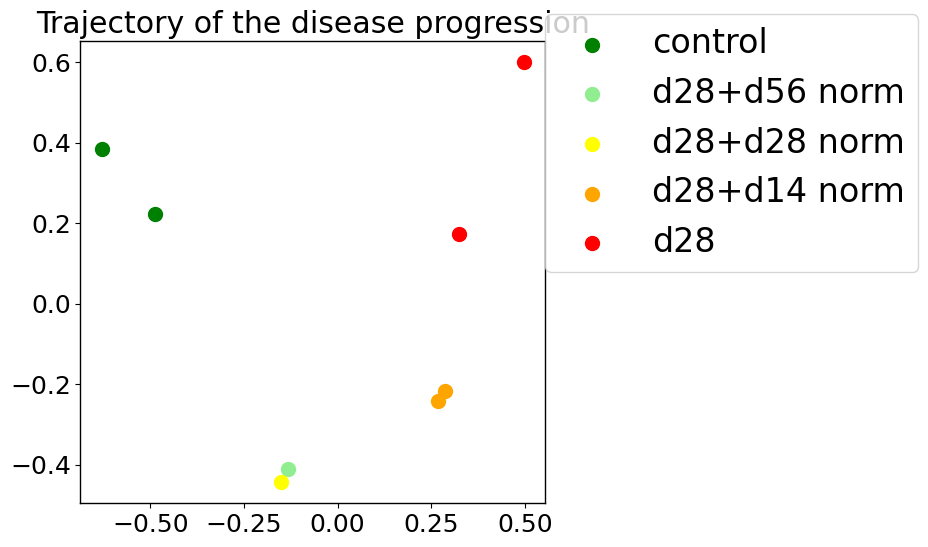

In [34]:
trajectory(mice,colors=['green','lightgreen','yellow','orange','red','pink','green','brown'],label_act=False,font_size=18,knn=10,figsize=(6,6),legend_order=['control','d28+d56 norm','d28+d28 norm','d28+d14 norm','d28'], location_labels=(1,0.5))

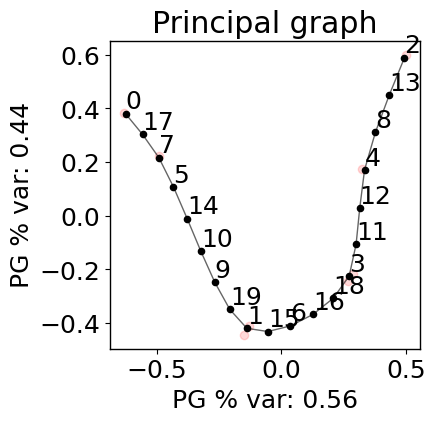

In [30]:

fit_pricipla_graph(mice, source_node =0,figsize=(4,4))

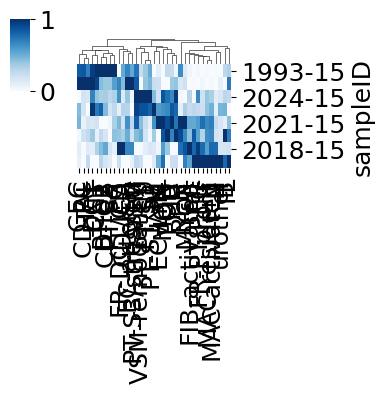

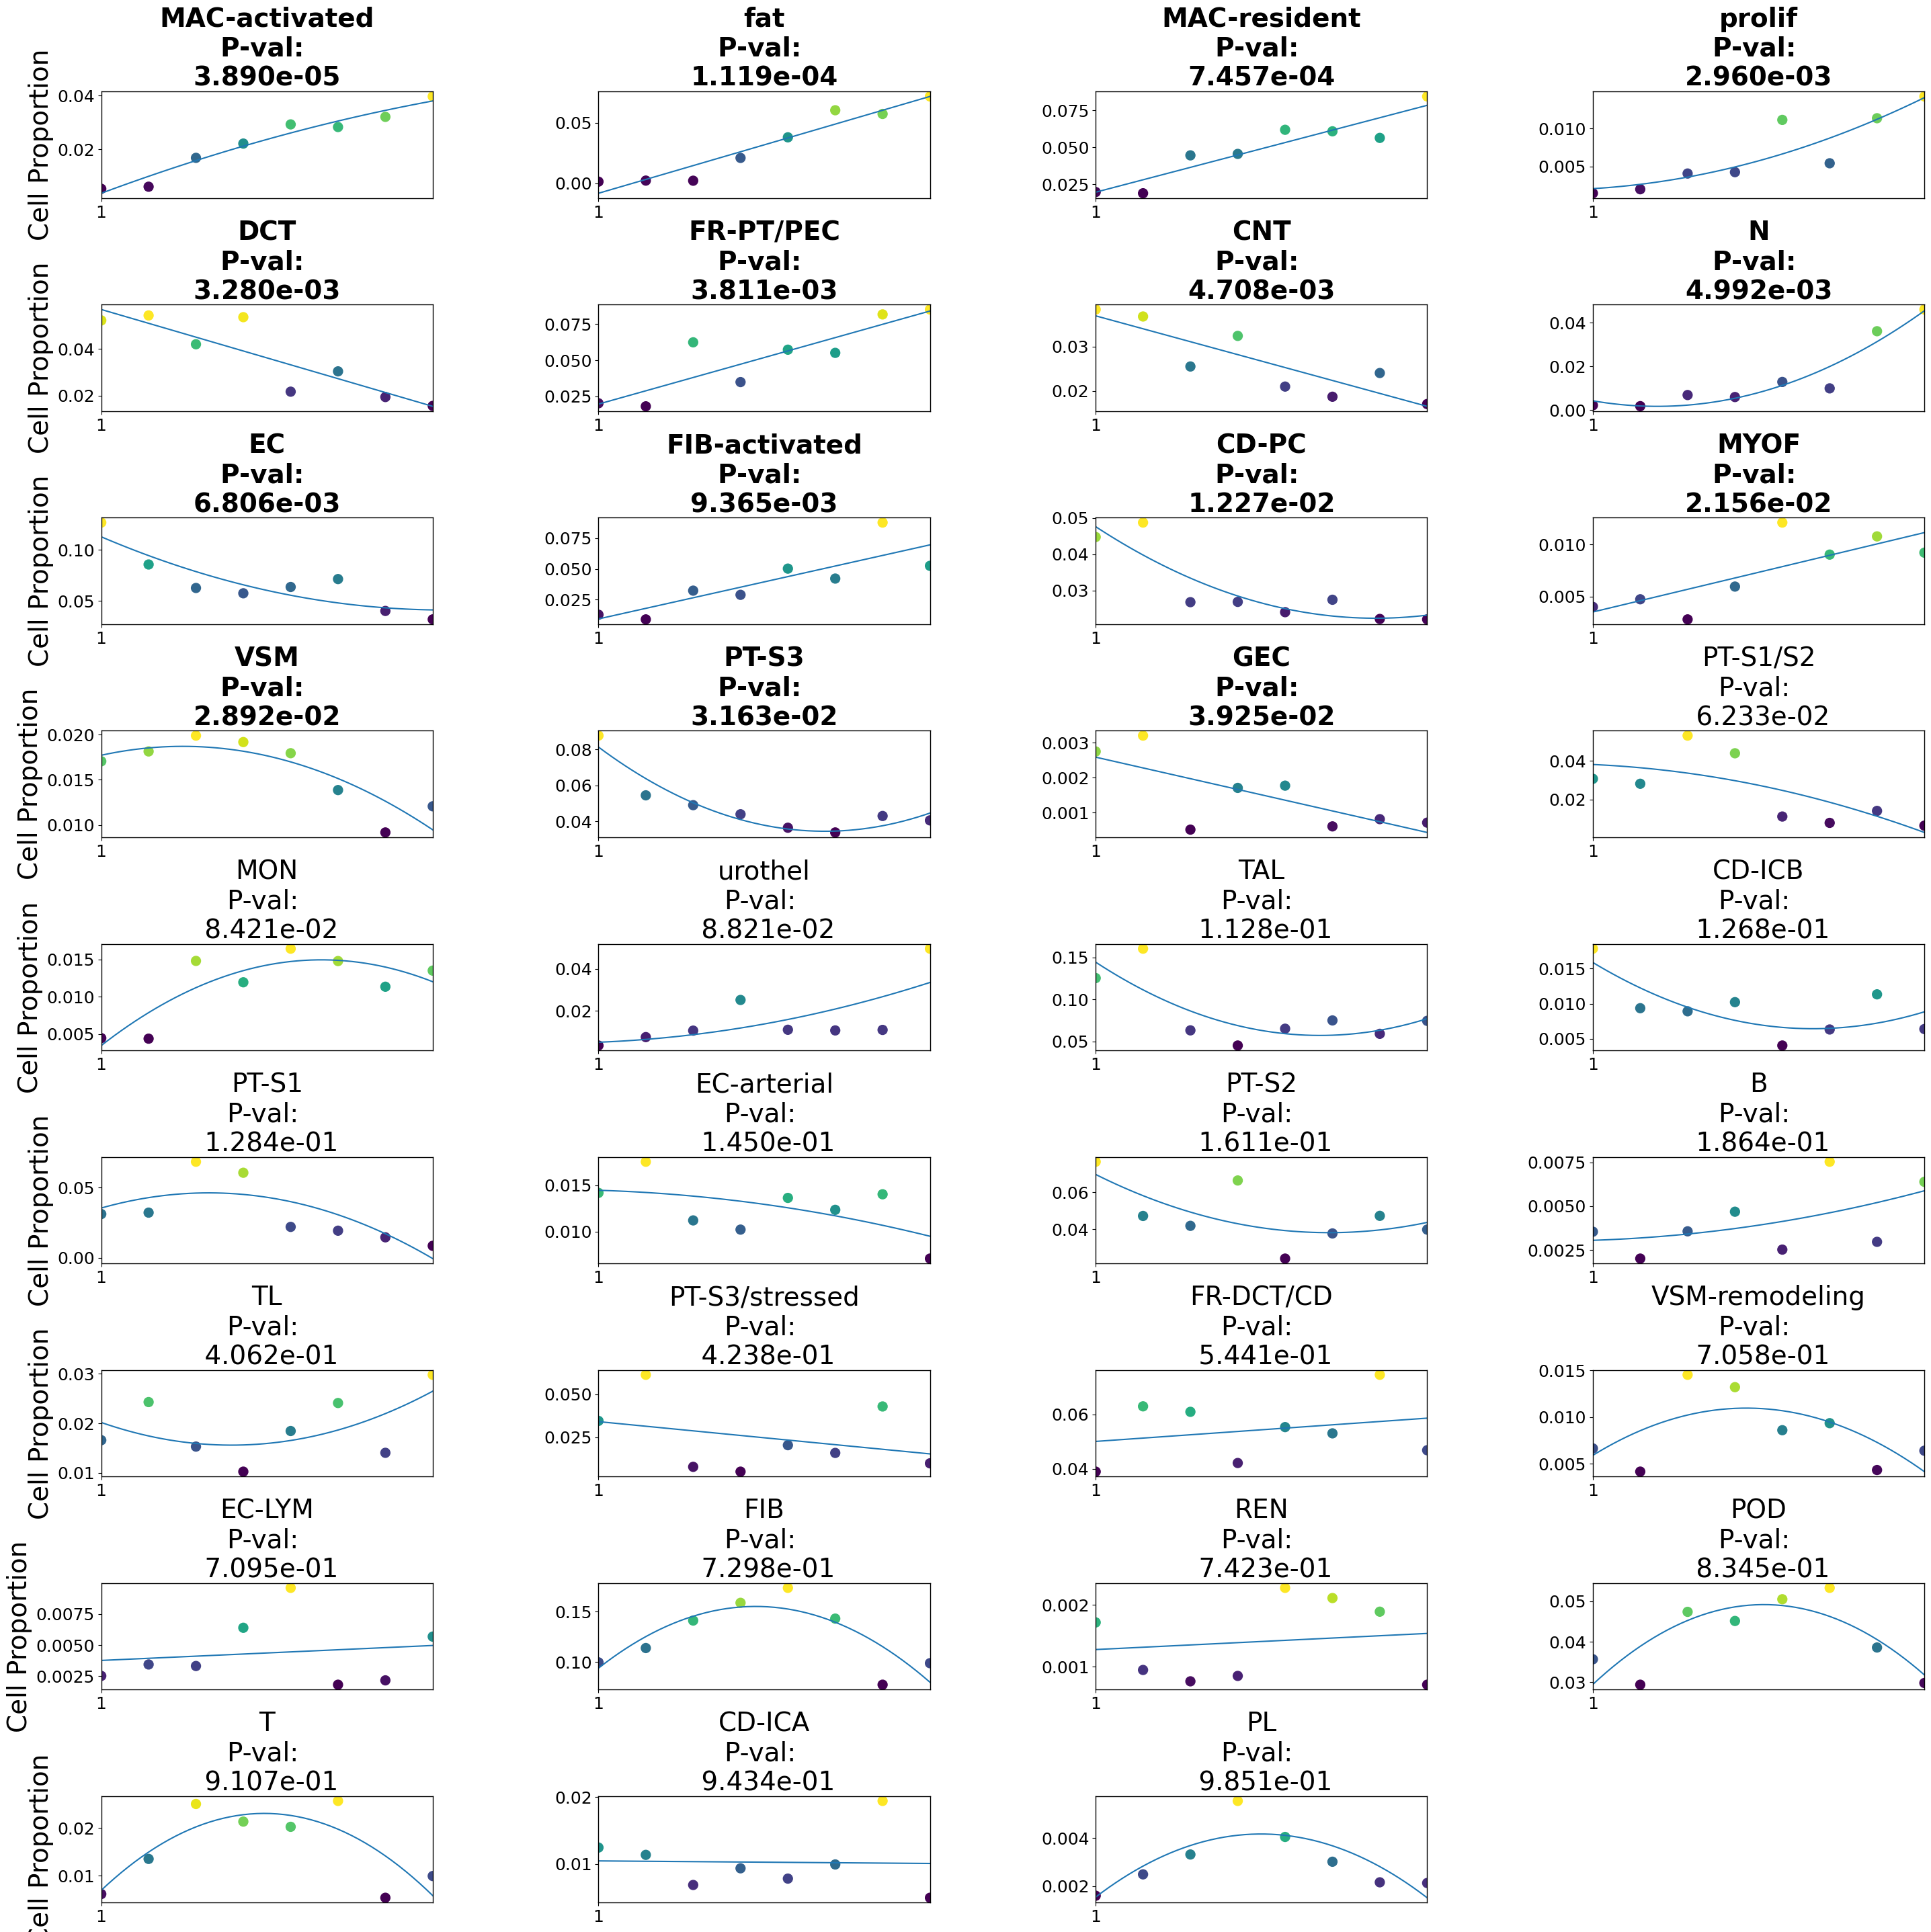

In [31]:

cell_importance(mice,height=35,width=35,fontsize=28,xlim=20,figsize=(4,4))

### Mice Glomerula

In [82]:
file_path = 'mu_glomerular.h5ad'
mice_g=sc.read_h5ad(file_path)
mice_g.obs['category'] = mice_g.obs['category'].replace('14 days ', '14 days')
wasserstein_distance(mice_g,emb_matrix='X_pca_harmony',
clusters_col='annotation_highres',sample_col='sample_ID',status='category',metric='euclidean')

In [83]:
mice_g

AnnData object with n_obs × n_vars = 25932 × 19059
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'cell_quality', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden_1_5', 'leiden_3', 'SoupX_run', 'n_counts', 'predicted_labels', 'majority_voting', 'conf_score', 'predicted_labels_immune', 'majority_voting_immune', 'conf_score_immune', 'over_clustering', 'predicted_labels_heart', 'majority_voting_heart', 'conf_score_heart', 'S_score', 'G2M_score', 'phase', 'sample_ID', 'disease_model', 'origin', 'category', 'annotation_lowres', 'annotation_highres'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'annotation_highres_colors', 'annotation_lowres_colors', 'category_colors', '

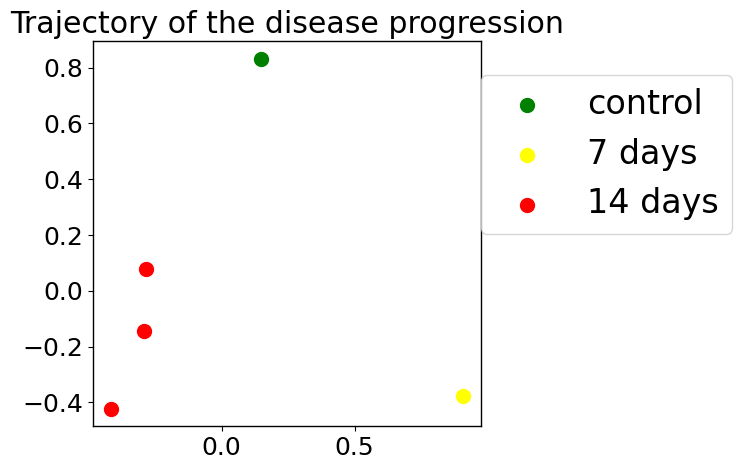

In [ ]:
trajectory(mice_g,colors=['green','yellow','red'],label_act=False,font_size=18,knn=10,figsize=(5,5),legend_order=['control','7 days','14 days'], location_labels=(1,0.5))

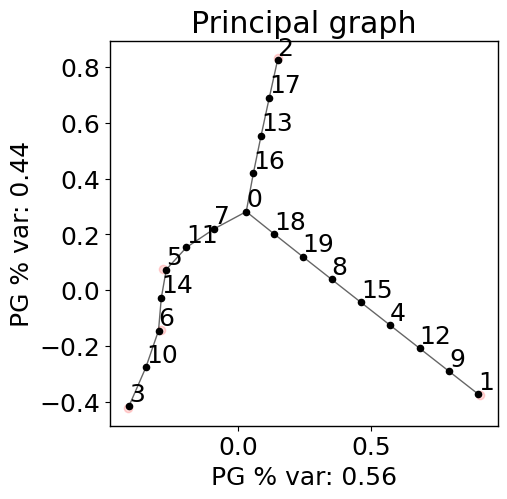

In [60]:
fit_pricipla_graph(mice_g, source_node =2,figsize=(5,5))

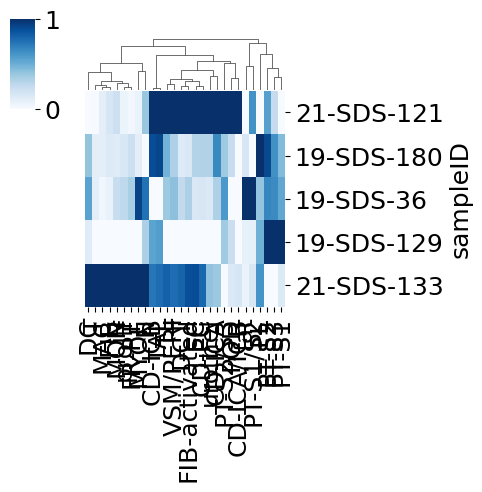

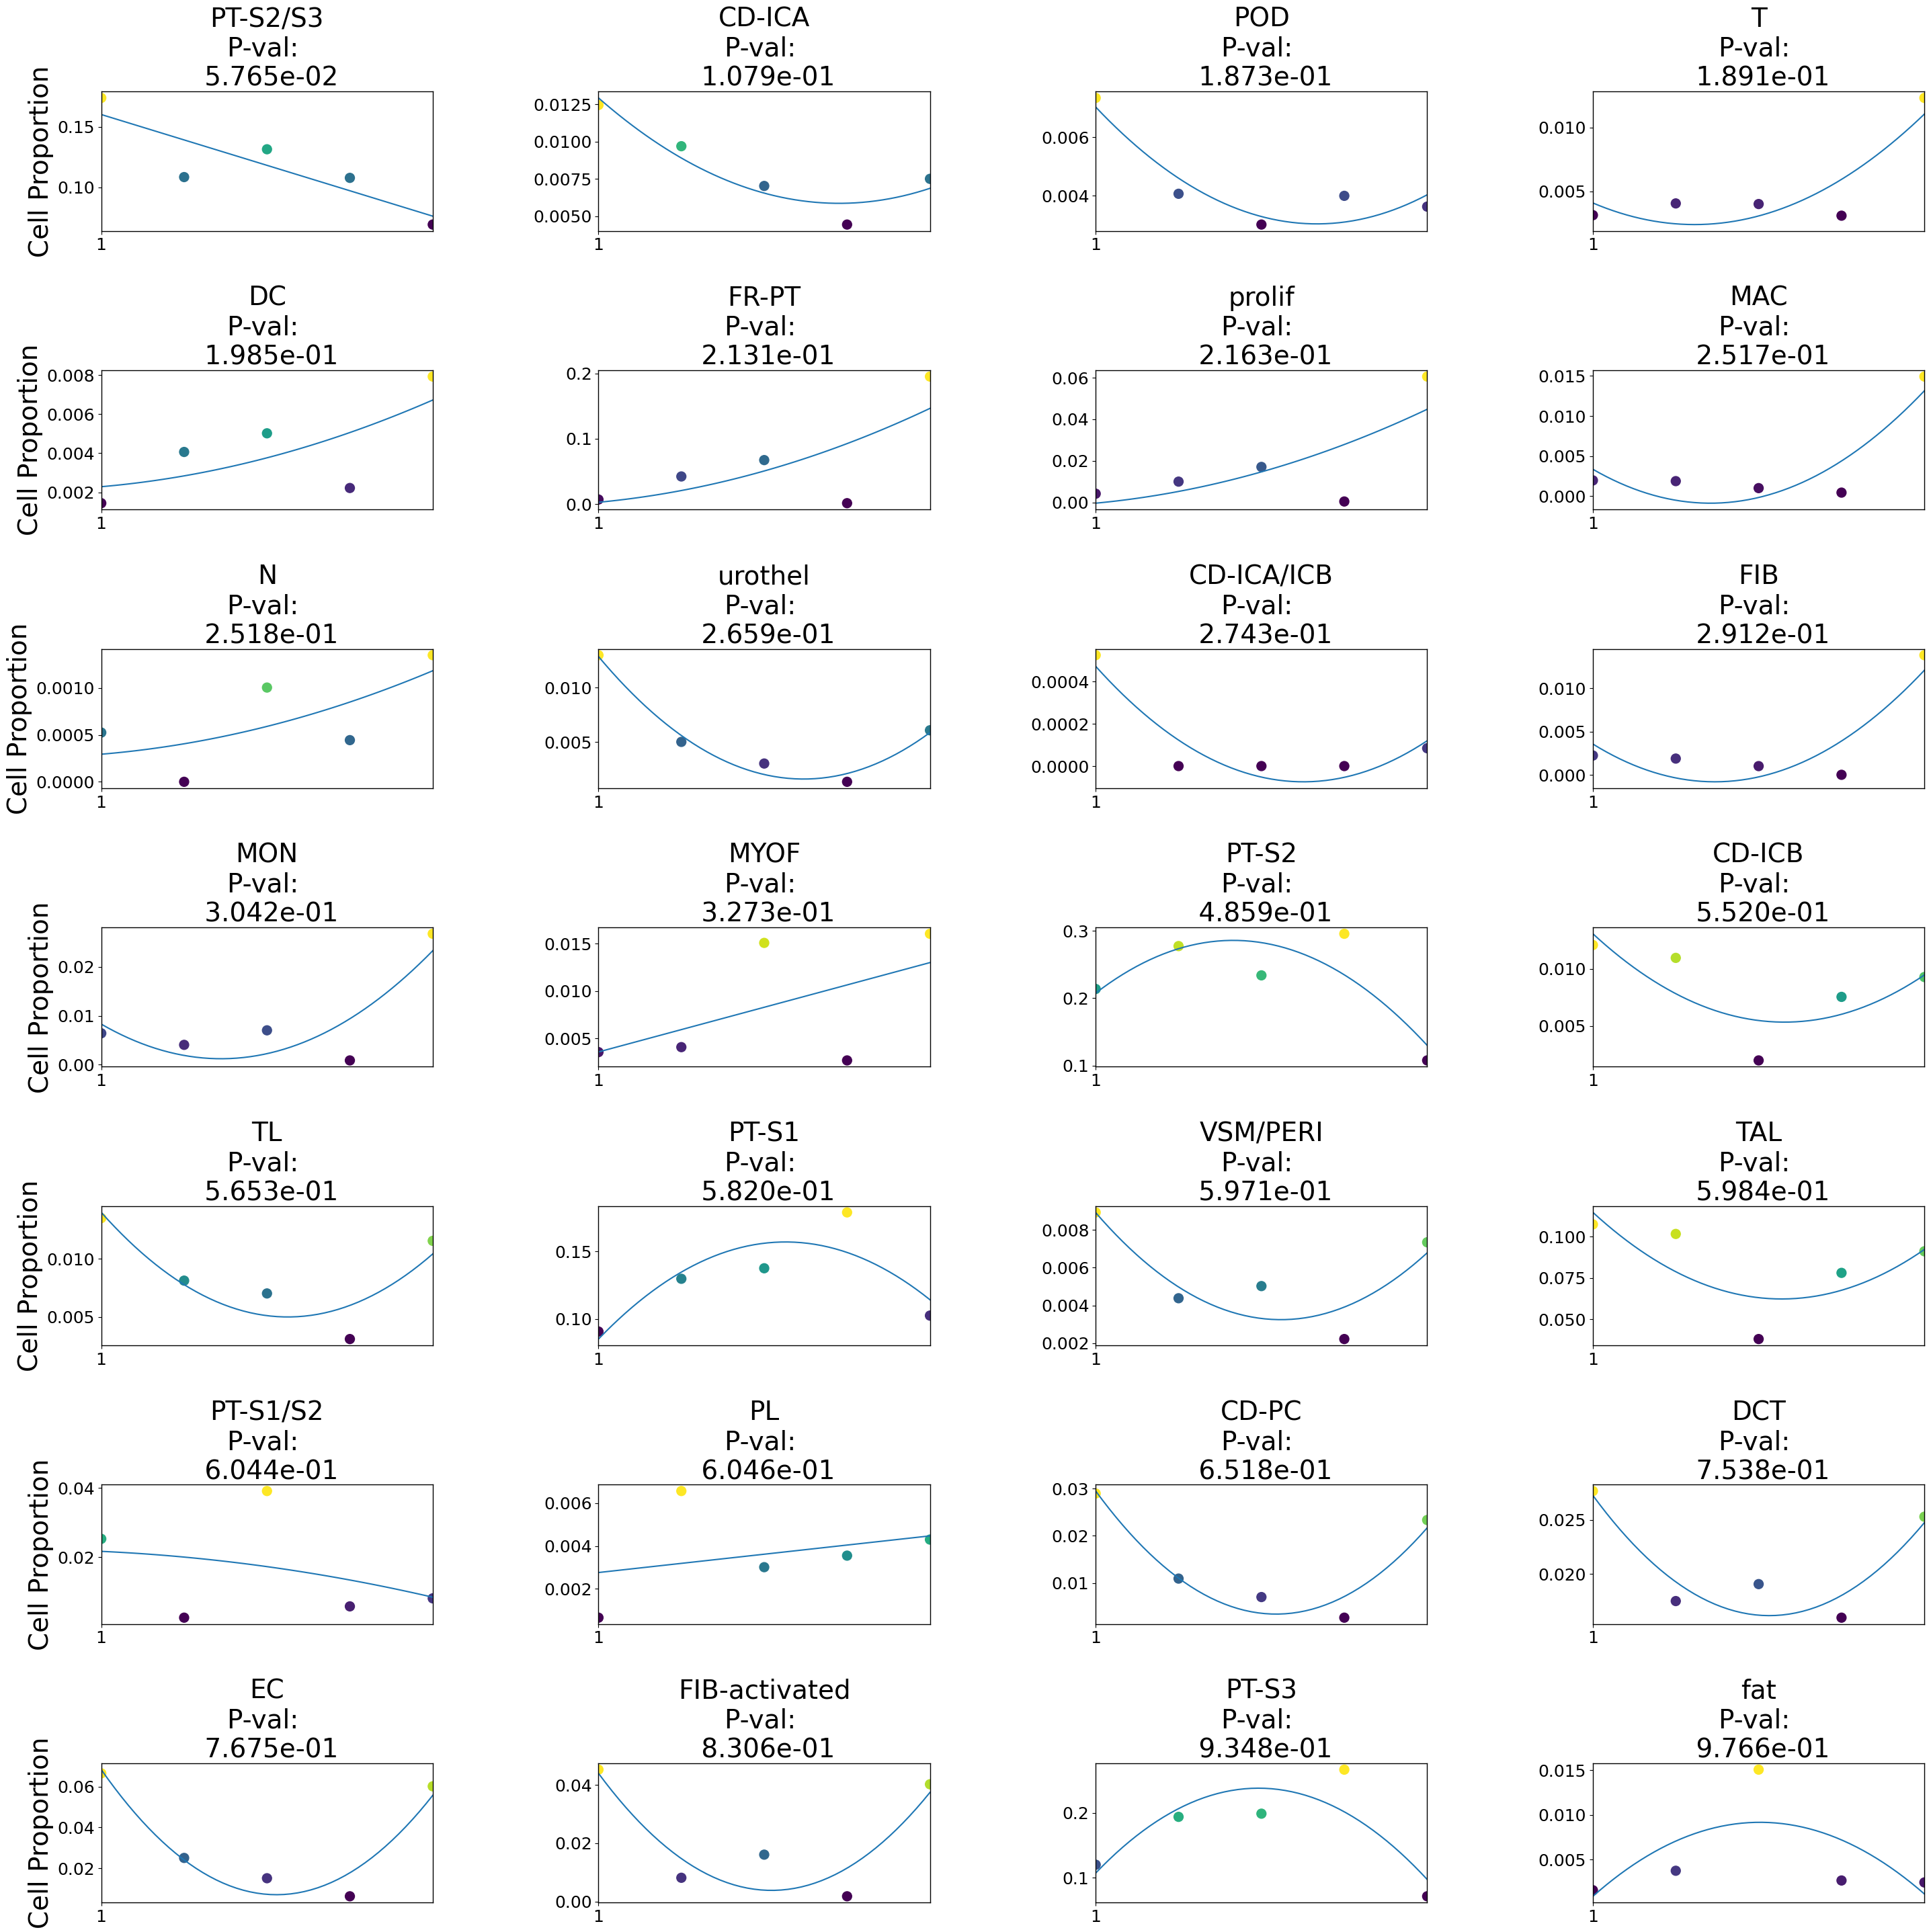

In [61]:
cell_importance(mice_g,height=35,width=35,fontsize=28,xlim=20,figsize=(5,5))

### Human (till here,  seems we need to combine mice g with human ,but wait!)

In [72]:
human=sc.read_h5ad('hu_kidney_final.h5ad')

In [102]:
import pandas as pd
import numpy as np

human.obs['eGFR_clean'] = (
    human.obs['eGFR']
    .astype(str)
    .str.replace('>', '', regex=False)
    .str.strip()
)

# turn "nan" strings back into real NaN if needed
human.obs['eGFR_clean'] = human.obs['eGFR_clean'].replace('nan', np.nan)
human = human[~human.obs['eGFR_clean'].isin([np.nan])]

human.obs['eGFR_clean'] = pd.to_numeric(human.obs['eGFR_clean'], errors='coerce')

human.obs['eGFR_group'] = pd.cut(
    human.obs['eGFR_clean'],
    bins=[-np.inf, 60, 90, np.inf],
    labels=['≤60', '60-90', '≥90'],
    right=False
)


In [98]:
#human.obs['eGFR_group'] = pd.cut(pd.to_numeric(human.obs['eGFR'].astype(str).str.replace('>', ''), errors='coerce'), bins=[-np.inf, 30, 60, np.inf], labels=['<30', '30-60', '>60'])

In [108]:
human.obs['eGFR_clean'].unique()

array([87. , 54.5, 90. , 50. , 93. , 31.3, 84. , 49. , 53. , 80.2, 73. ,
       38. , 54. , 81. ])

In [116]:
wasserstein_distance(human,emb_matrix='X_pca_harmony',
clusters_col='annotation_highres',sample_col='sample_ID',status='eGFR_group',metric='euclidean')

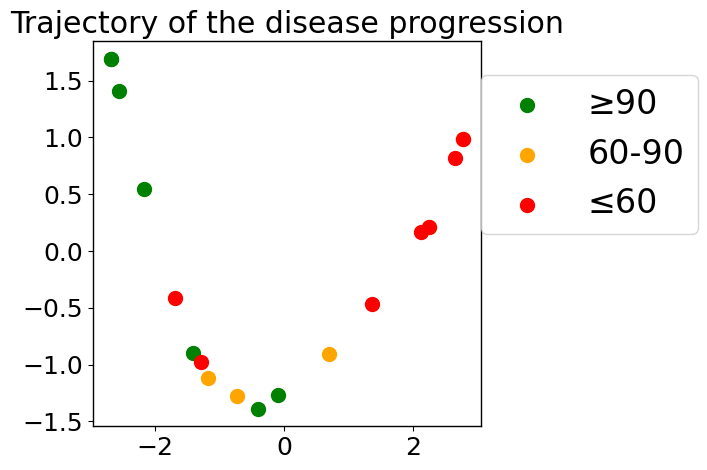

In [117]:
trajectory(human,colors=['green','orange','red'],label_act=False,font_size=18,knn=3,figsize=(5,5),legend_order=['≥90','60-90','≤60'], location_labels=(1,0.5))

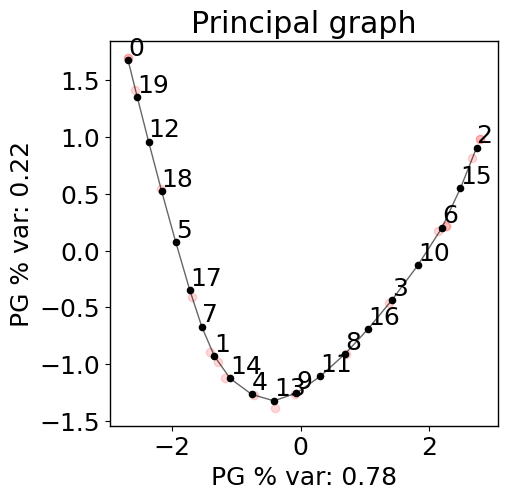

In [119]:
fit_pricipla_graph(human, source_node =0,figsize=(5,5))

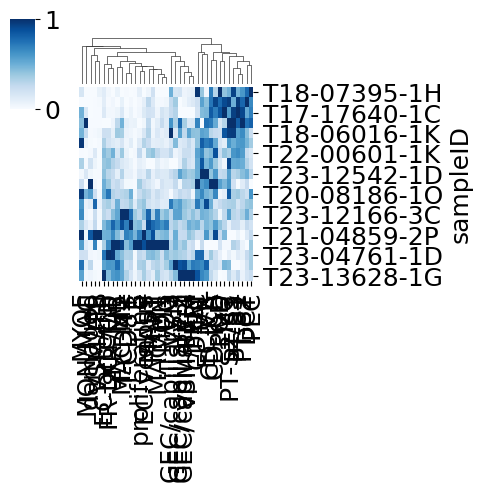

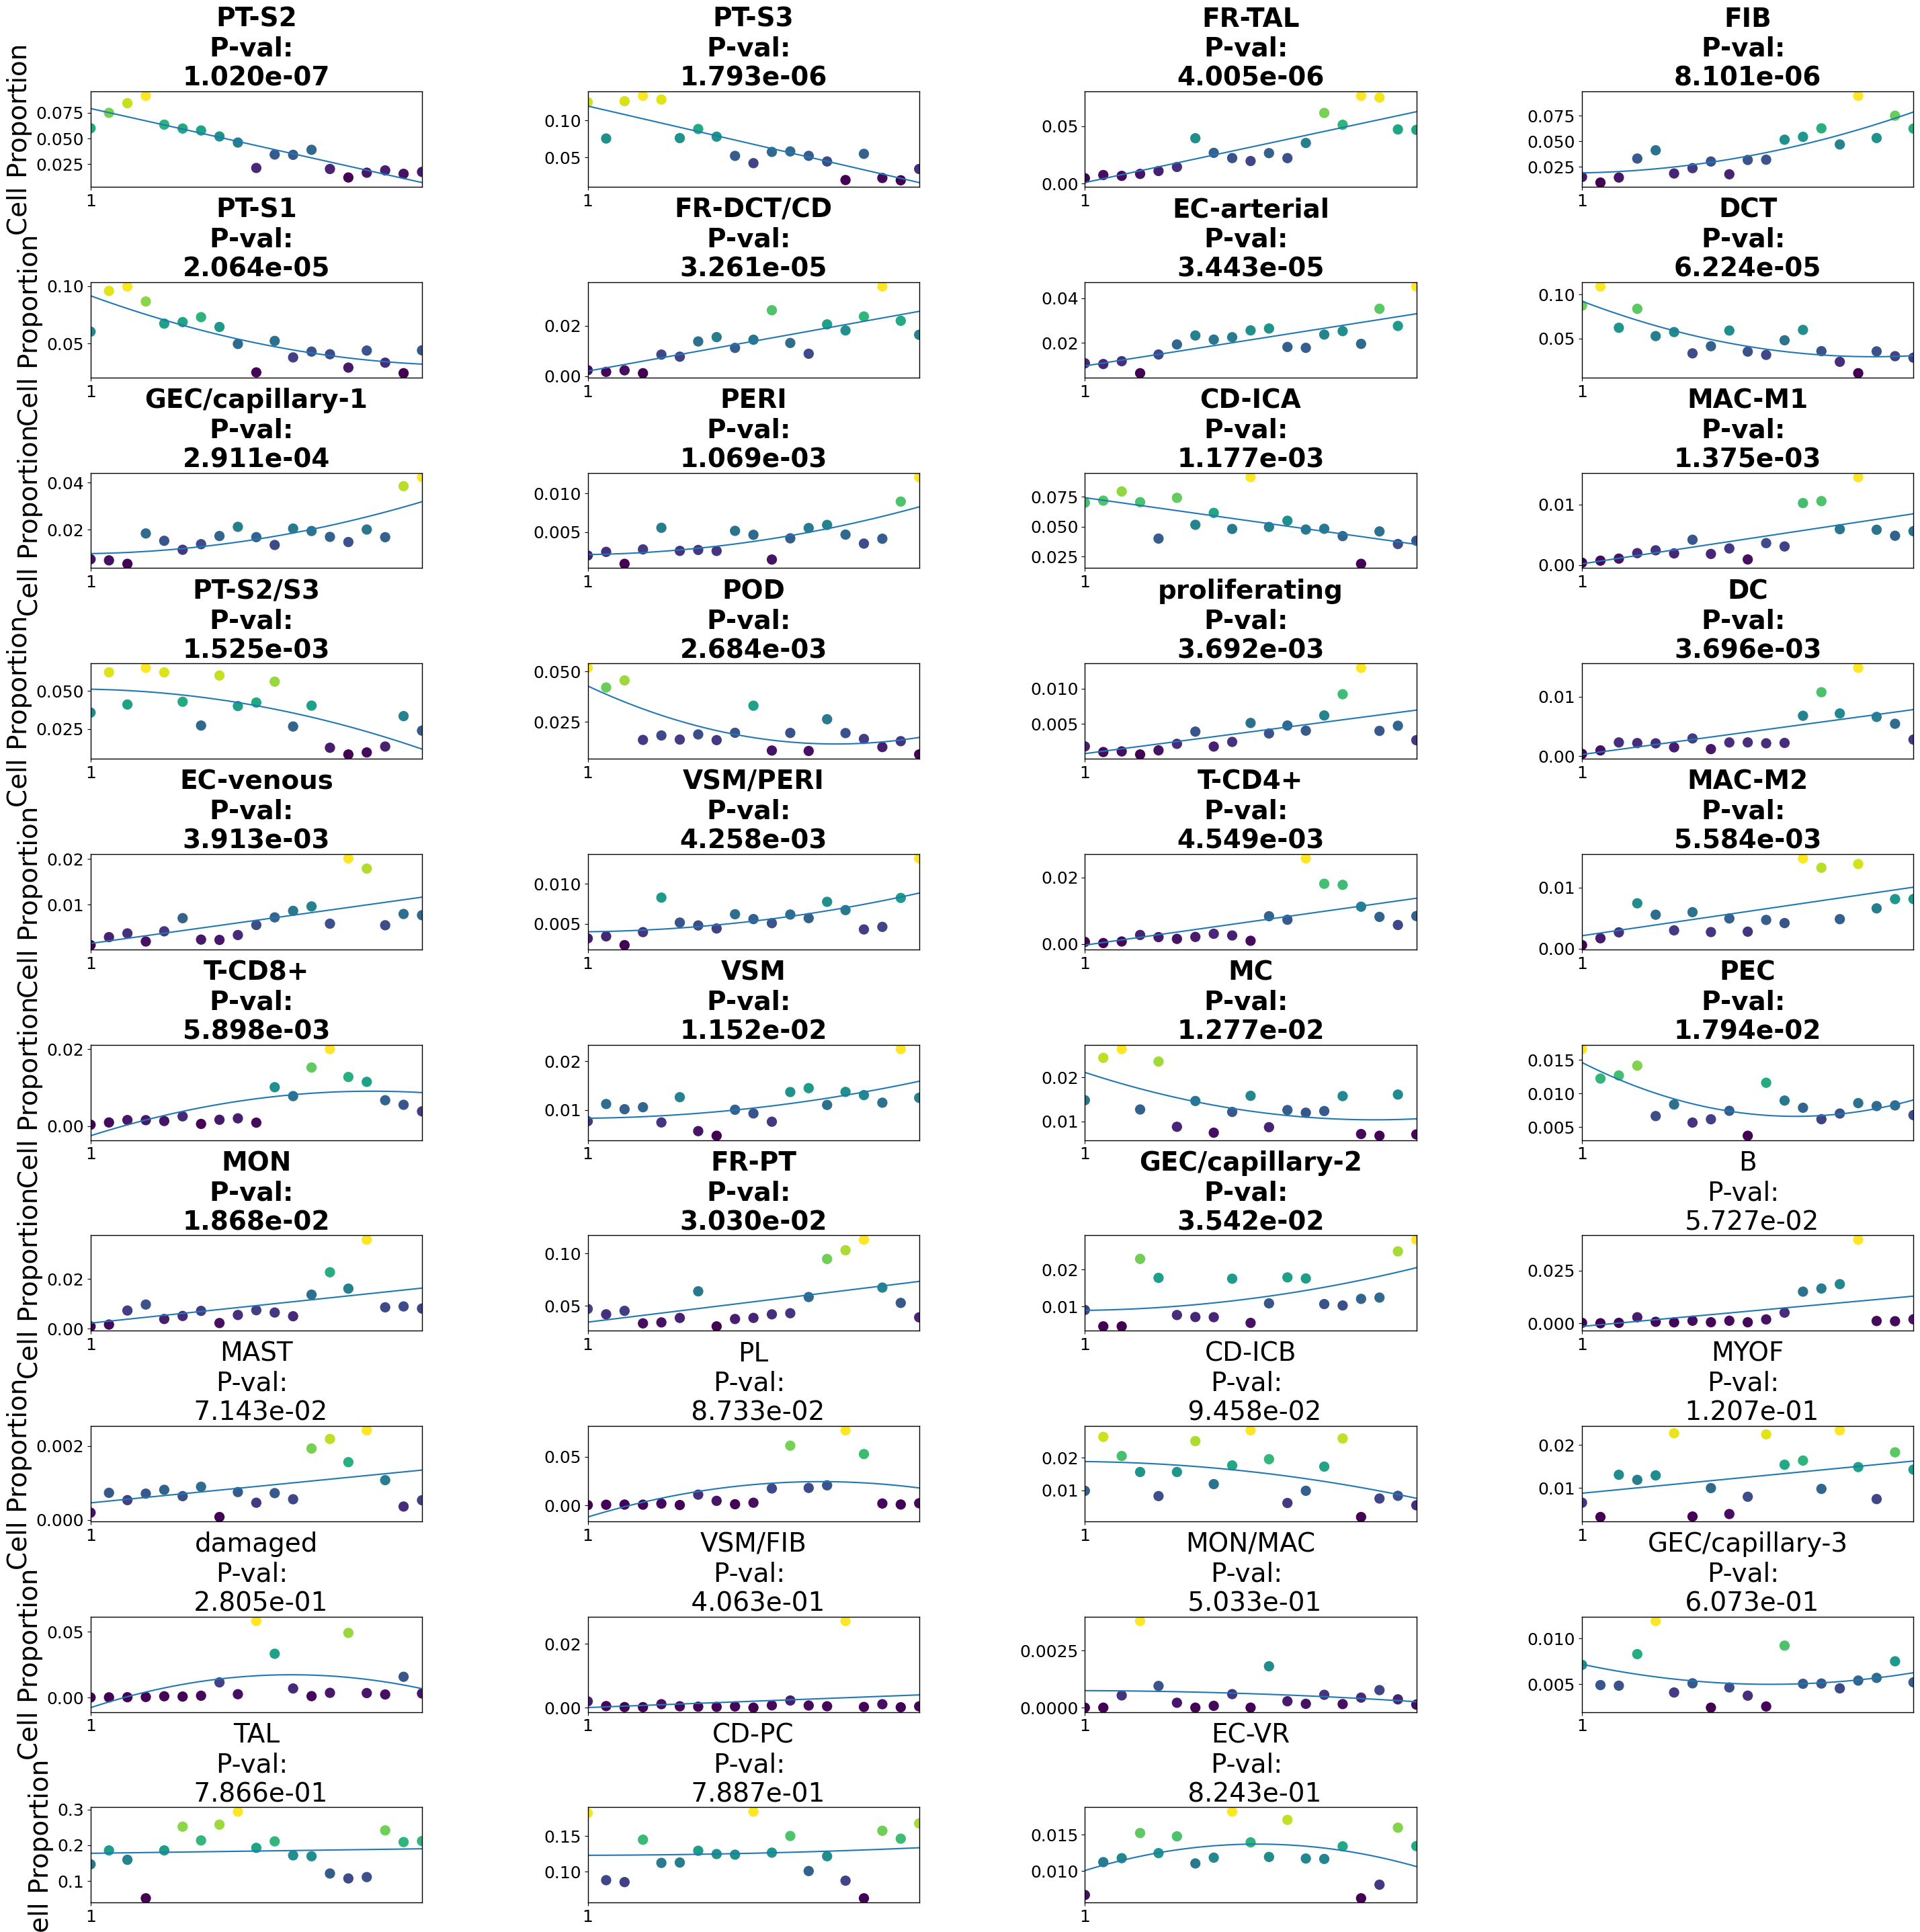

In [120]:
cell_importance(human,height=35,width=35,fontsize=28,xlim=20,figsize=(5,5))

In [126]:
human

AnnData object with n_obs × n_vars = 148009 × 18082
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_genes', 'cell_quality', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden_1_5', 'leiden_3', 'SoupX_run', 'sample_ID', 'age', 'gender', 'carcinoma', 'IFTA', 'eGFR', 'CKD_stage', 'kreatinine', 'annotation_lowres', 'annotation_highres', 'eGFR_clean', 'eGFR_group'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'annotation_highres_colors', 'hvg', 'leiden_1_5', 'leiden_1_5_colors', 'leiden_3', 'leiden_3_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'data', 'annot', 'proportions', 'cost', 'EMD_df', 'EMD', 'real_labels', 'embedding', 'pseudotime', 'cellnames', 'ord

In [127]:
mice

AnnData object with n_obs × n_vars = 35848 × 19059
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'cell_quality', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden_1_5', 'leiden_3', 'SoupX_run', 'annotation_lowres', 'annotation_highres', 'sample_ID', 'disease_model', 'origin', 'category'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'annotation_highres_colors', 'annotation_lowres_colors', 'category_colors', 'dendrogram_annotation_lowres', 'hvg', 'leiden_1_5', 'leiden_1_5_colors', 'leiden_3', 'leiden_3_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_ID_colors', 'umap'
    obsm: 'X_pacmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    laye

In [110]:
#mice.var_names = mice.var.Symbol_human

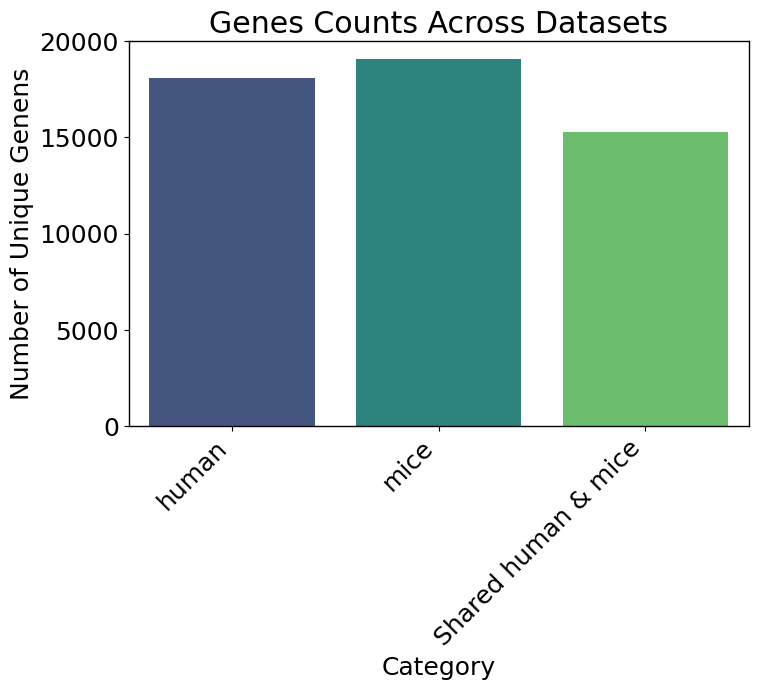

In [130]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming adata1, adata2, and adata3 are your AnnData objects
donors_1 = set(human.var_names.str.upper())
donors_2 = set(mice.var_names.str.upper())
# Find shared donors
shared_12 = donors_1 & donors_2

# Count occurrences
counts = {
    "human": len(donors_1),
    "mice": len(donors_2),
    "Shared human & mice": len(shared_12),
}

# Convert to DataFrame
df = pd.DataFrame(list(counts.items()), columns=["Category", "Count"])

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Category", y="Count", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Unique Genens")
plt.title("Genes Counts Across Datasets")
plt.show()


### Human

In [132]:
human.var_names=human.var_names.str.upper()
mice.var_names=mice.var_names.str.upper()

In [134]:
human_filtered = human[:, list(shared_12)].copy()

In [135]:

# Verify the new shape
print(f"Original adata3 shape: {human.shape}")
print(f"Filtered adata3 shape: {human_filtered.shape}")

Original adata3 shape: (148009, 18082)
Filtered adata3 shape: (148009, 15262)


In [136]:
X_dense = human_filtered.X.toarray() 
print(f"Min value: {X_dense.min()}, Max value: {X_dense.max()}")
# Check if values are integers (suggesting raw counts)
print(f"All integers? {np.all(X_dense == X_dense.astype(int))}")

Min value: 0.0, Max value: 441.1802352780551
All integers? False


### Mice

In [137]:
print("Number of duplicate gene names:", mice.var_names.duplicated().sum())

Number of duplicate gene names: 0


In [138]:
mice = mice[:, ~mice.var_names.duplicated(keep='first')].copy()
mice_filtered = mice[:, list(shared_12)].copy()

In [139]:

# Verify the new shape
print(f"Original adata3 shape: {mice.shape}")
print(f"Filtered adata3 shape: {mice_filtered.shape}")

Original adata3 shape: (35848, 19059)
Filtered adata3 shape: (35848, 15262)


In [140]:
X_dense = mice_filtered.X.toarray() 
print(f"Min value: {X_dense.min()}, Max value: {X_dense.max()}")
# Check if values are integers (suggesting raw counts)
print(f"All integers? {np.all(X_dense == X_dense.astype(int))}")

Min value: 0.0, Max value: 197.08373854785683
All integers? False


In [144]:
mice_filtered.layers

Layers with keys: after_soupx, b4_soupx

### Combine 

In [142]:
human_filtered

AnnData object with n_obs × n_vars = 148009 × 15262
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_genes', 'cell_quality', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden_1_5', 'leiden_3', 'SoupX_run', 'sample_ID', 'age', 'gender', 'carcinoma', 'IFTA', 'eGFR', 'CKD_stage', 'kreatinine', 'annotation_lowres', 'annotation_highres', 'eGFR_clean', 'eGFR_group'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'annotation_highres_colors', 'hvg', 'leiden_1_5', 'leiden_1_5_colors', 'leiden_3', 'leiden_3_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap', 'data', 'annot', 'proportions', 'cost', 'EMD_df', 'EMD', 'real_labels', 'embedding', 'pseudotime', 'cellnames', 'ord

In [143]:
mice

AnnData object with n_obs × n_vars = 35848 × 19059
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'cell_quality', 'doublet_score', 'predicted_doublet', 'clf_doublet', 'clf_score', 'leiden_1_5', 'leiden_3', 'SoupX_run', 'annotation_lowres', 'annotation_highres', 'sample_ID', 'disease_model', 'origin', 'category'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'annotation_highres_colors', 'annotation_lowres_colors', 'category_colors', 'dendrogram_annotation_lowres', 'hvg', 'leiden_1_5', 'leiden_1_5_colors', 'leiden_3', 'leiden_3_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_ID_colors', 'umap'
    obsm: 'X_pacmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    laye

In [145]:
human_filtered.obs['Donor_'] = human_filtered.obs['sample_ID'].astype(str) + '_' + 'human'
human_filtered.obs['batch'] = 'human'
mice_filtered.obs['Donor_'] = mice_filtered.obs['sample_ID'].astype(str) + '_' + 'mice'     
mice_filtered.obs['batch'] = 'mice'
# Step 4: Combine the 'Donor', 'status', and 'batch' columns
donor_combined = np.concatenate([human_filtered.obs['Donor_'].values, mice_filtered.obs['Donor_'].values])
status_combined = np.concatenate([human_filtered.obs['eGFR_group'].values, mice_filtered.obs['category'].values])
batch_combined = np.concatenate([human_filtered.obs['batch'].values, mice_filtered.obs['batch'].values])
cell_combined = np.concatenate([human_filtered.obs['annotation_highres'].values, mice_filtered.obs['annotation_highres'].values])
cell_combined2 = np.concatenate([human_filtered.obs['annotation_lowres'].values, mice_filtered.obs['annotation_lowres'].values])
human_raw = human_filtered.layers['b4_soupx'].toarray()  # Shape: (n_human_cells, n_genes)
mice_raw = mice_filtered.layers['b4_soupx'].toarray()    # Shape: (n_mice_cells, n_genes)
X_genes_combined = np.concatenate([human_raw, mice_raw], axis=0)

In [146]:
combined_adata = sc.AnnData(X_genes_combined)
combined_adata.obs['Donor'] = donor_combined
combined_adata.obs['status'] = status_combined
combined_adata.obs['batch'] = batch_combined
combined_adata.obs['cell_subtype'] = cell_combined
combined_adata.obs['major_celltype'] = cell_combined2
#sc.pp.pca(combined_adata, n_comps=50)  # Compute first 50 principal components

In [147]:
combined_adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype'

In [149]:
X_dense = combined_adata.X
print(f"Min value: {X_dense.min()}, Max value: {X_dense.max()}")
# Check if values are integers (suggesting raw counts)
print(f"All integers? {np.all(X_dense == X_dense.astype(int))}")

Min value: 0.0, Max value: 21145.0
All integers? True


In [150]:
combined_adata.obs['Donor'].unique()

array(['T23-18039-1L_human', 'T23-04761-1D_human', 'T23-00595-1H_human',
       'T17-17640-1C_human', 'T23-12166-3C_human', 'HNE235_human',
       'T18-01733-1K_human', 'T21-17895-1D_human', 'T23-11482-1C_human',
       'T23-13628-1G_human', 'T21-04859-2P_human', 'T23-17210-1H_human',
       'T18-06016-1K_human', 'T21-12963-1K_human', 'T22-00601-1K_human',
       'T18-07395-1H_human', 'T23-12542-1D_human', 'T21-13356-1U_human',
       'T20-08186-1O_human', '2031-15_mice', '2022-15_mice',
       '1993-15_mice', '2018-15_mice', '2021-15_mice', '2024-15_mice',
       '2016-15_mice', '1991-15_mice'], dtype=object)

In [152]:
combined_adata.obs['cell_subtype'].unique()

array(['CD-PC', 'FIB', 'EC-arterial', 'TAL', 'MON', 'PT-S1', 'MYOF',
       'VSM', 'DCT', 'PT-S3', 'GEC/capillary-1', 'CD-ICA', 'FR-DCT/CD',
       'FR-PT', 'EC-VR', 'GEC/capillary-2', 'FR-TAL', 'PL',
       'proliferating', 'MAC-M2', 'PT-S2/S3', 'PT-S2', 'POD', 'VSM/PERI',
       'MC', 'PEC', 'PERI', 'VSM/FIB', 'MAC-M1', 'B', 'T-CD4+',
       'EC-venous', 'GEC/capillary-3', 'CD-ICB', 'T-CD8+', 'damaged',
       'MAST', 'DC', 'MON/MAC', 'FR-PT/PEC', 'EC', 'N', 'urothel',
       'PT-S1/S2', 'fat', 'MAC-resident', 'FIB-activated', 'T', 'CNT',
       'MAC-activated', 'PT-S3/stressed', 'TL', 'VSM-remodeling',
       'prolif', 'EC-LYM', 'GEC', 'REN'], dtype=object)

In [ ]:
combined_adata.write_h5ad('/data/scRNA/To_Mehdi/Emilia/new_data/combined_human_mice_v0.h5ad')

### Test

In [4]:
adata=sc.read_h5ad('/data/scRNA/To_Mehdi/Emilia/new_data/combined_human_mice_v0.h5ad')
EMD = np.load('/data/scRNA/To_Mehdi/Emilia/new_data/trained_models/snRNA_human_mice/EMD_20_combined.npy')
z_laten = np.load('/data/scRNA/To_Mehdi/Emilia/new_data/trained_models/snRNA_human_mice/z_laten_20_combined.npy')
component_assignment = np.load('/data/scRNA/To_Mehdi/Emilia/new_data/trained_models/snRNA_human_mice/component_assignment_20_combined.npy')
adata.uns['EMD'] = EMD
adata.obsm['z_laten'] = z_laten
adata.obs['component_assignment'] = component_assignment

In [5]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'EMD', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_har', 'X_umap_z_laten', 'z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
#adata.obsm['X_umap_har'] = adata.obsm['X_umap'].copy()
#sc.pp.neighbors(adata, use_rep='z_laten')
#sc.tl.umap(adata)
#adata.obsm['X_umap_z_laten'] = adata.obsm['X_umap'].copy()

In [ ]:
#adata.write_h5ad('/data/scRNA/To_Mehdi/Emilia/new_data/combined_human_mice_v0.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'EMD', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_har', 'X_umap_z_laten', 'z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

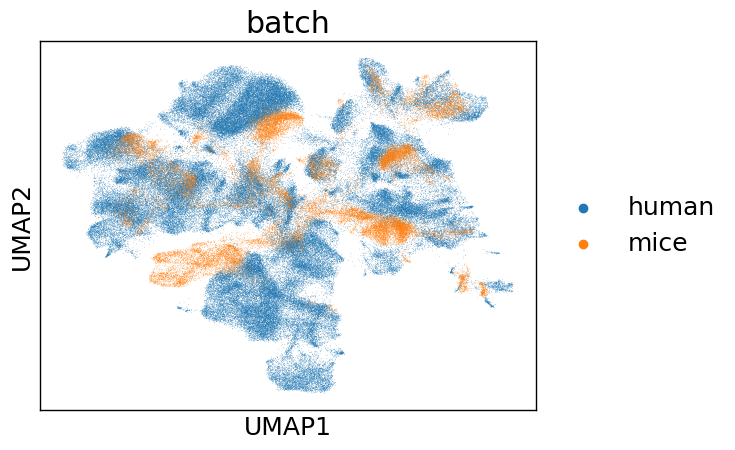

In [176]:
adata.obsm['X_umap']=adata.obsm['X_umap_z_laten']
sc.pl.umap(adata,color='batch')

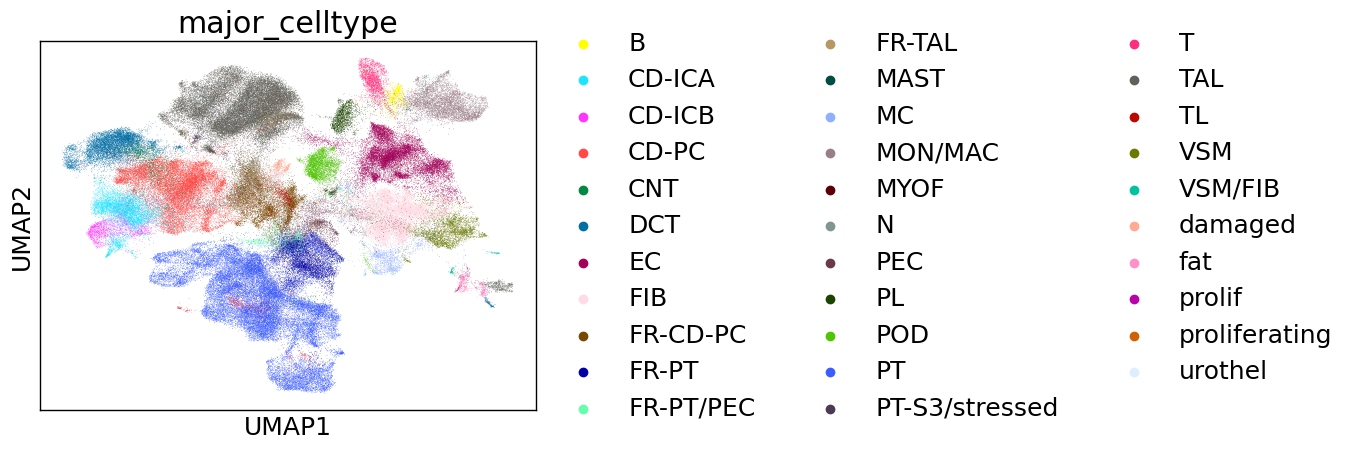

In [177]:
sc.pl.umap(adata,color='major_celltype')

In [180]:
adata.obs['component_assignment']=adata.obs['component_assignment'].astype(str)

In [ ]:
plot_umap_and_stacked_bar(adata_mice,component_col='component_assignment',cell_type_col='major_cell_type')

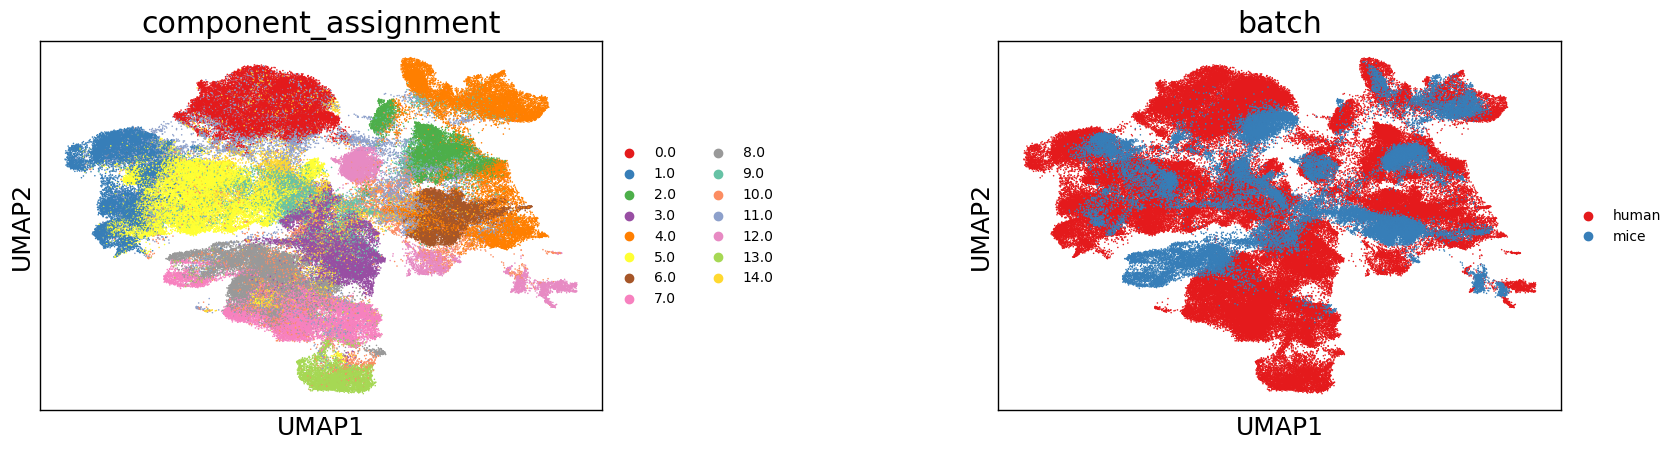

<Figure size 1400x800 with 0 Axes>

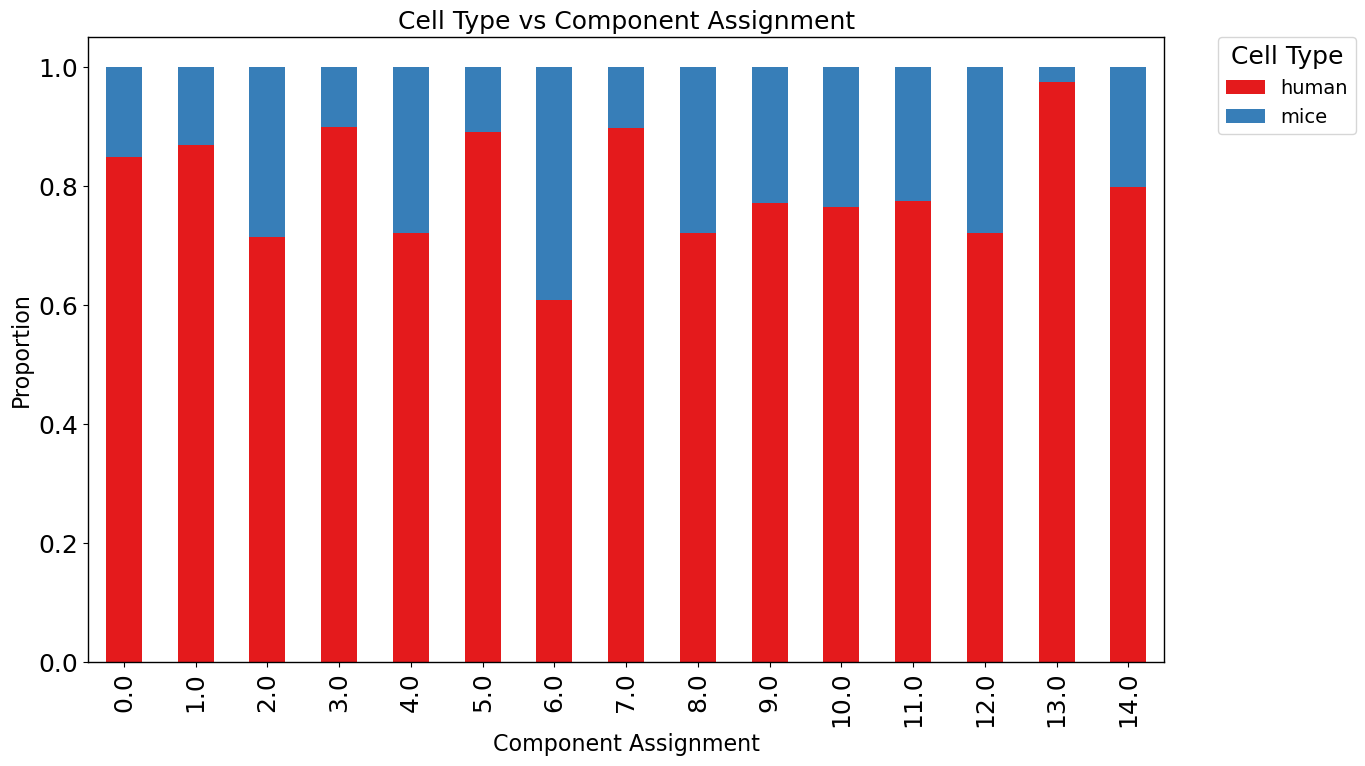

In [224]:
plot_umap_and_stacked_bar(adata,component_col='component_assignment',cell_type_col='batch')

In [227]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'log1p', 'neighbors', 'pca', 'umap', 'EMD', 'batch_colors', 'major_celltype_colors', 'component_assignment_colors', 'data', 'annot', 'proportions', 'cost', 'EMD_df', 'real_labels', 'embedding', 'pseudotime', 'cellnames', 'orders'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'z_laten', 'X_umap_har', 'X_umap_z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

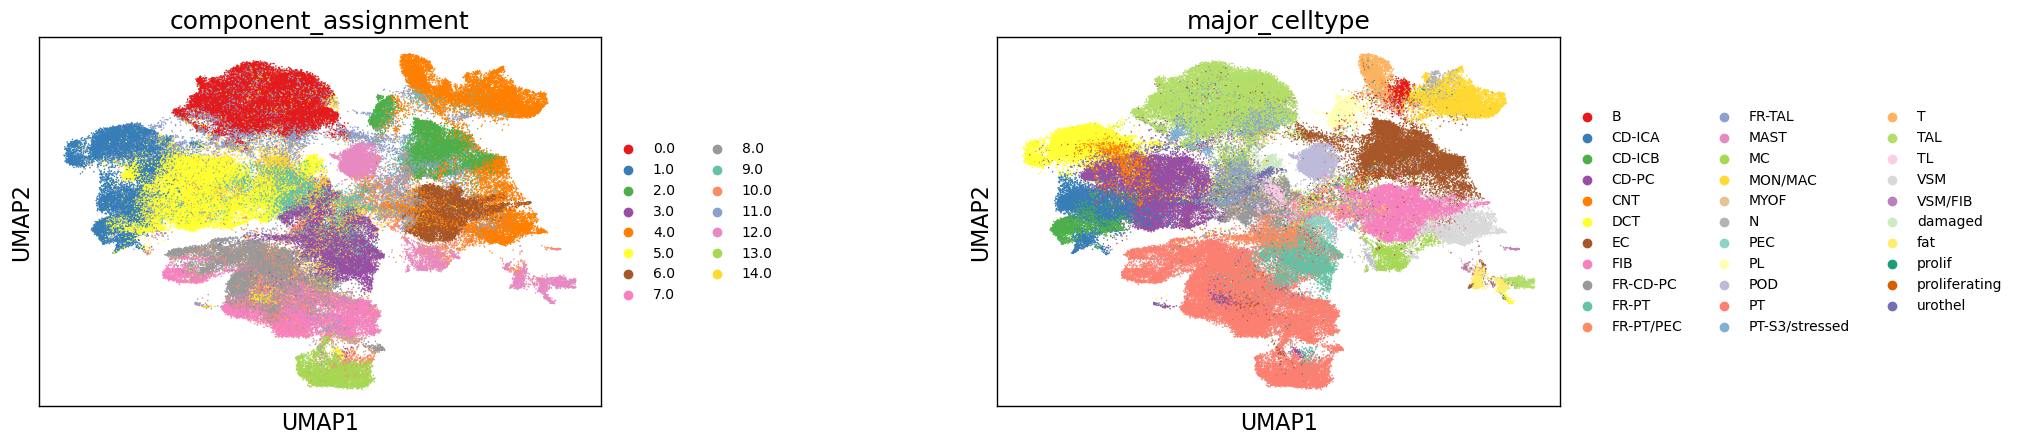

<Figure size 1400x800 with 0 Axes>

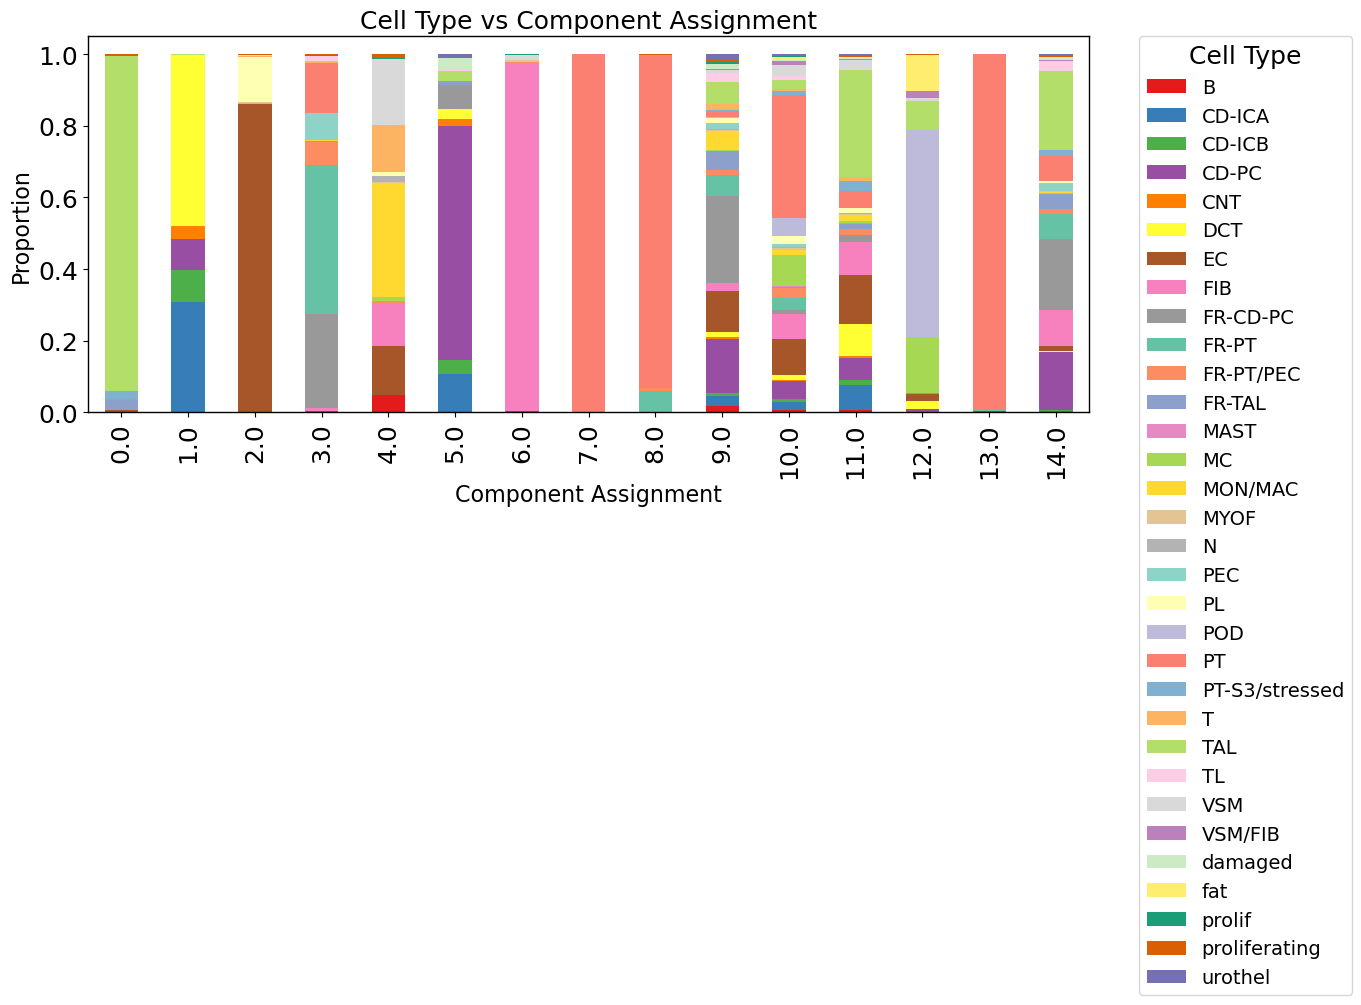

In [226]:
plot_umap_and_stacked_bar(adata,component_col='component_assignment',cell_type_col='major_celltype')

In [7]:
adata

AnnData object with n_obs × n_vars = 183857 × 15262
    obs: 'Donor', 'status', 'batch', 'cell_subtype', 'major_celltype', 'component_assignment'
    uns: 'EMD', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_har', 'X_umap_z_laten', 'z_laten'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [16]:
wasserstein_distance(adata,emb_matrix='X_pca_harmony',
clusters_col='component_assignment',sample_col='Donor',status='status',metric='cosine')

In [ ]:
trajectory(adata,colors=['#8fd19e','orange','#ff6b6b','#2e8b57','darkgreen','yellow','#e76f51','red'],label_act=False,font_size=18,knn=12,figsize=(8,8),legend_order=['≥90','60-90','≤60', 'control','d28+d56 norm','d28+d28 norm','d28+d14 norm','d28'], location_labels=(1,0.5))

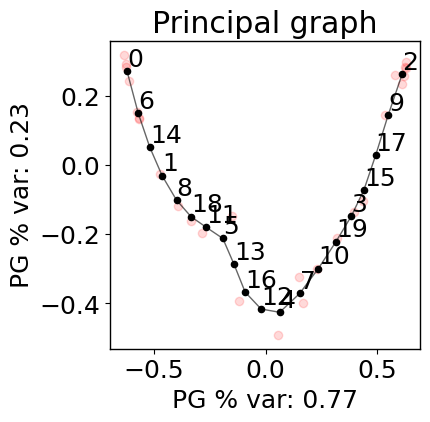

In [219]:
fit_pricipla_graph(adata, source_node =0,figsize=(4,4))

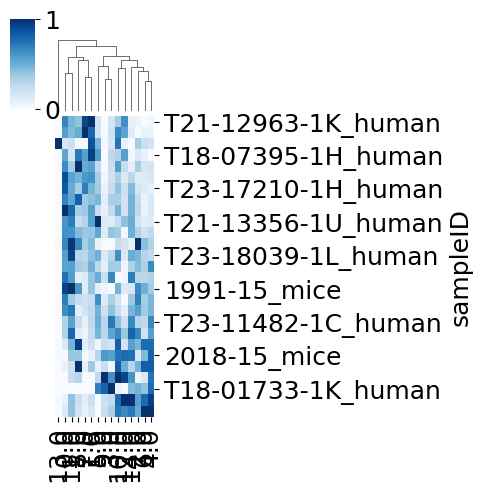

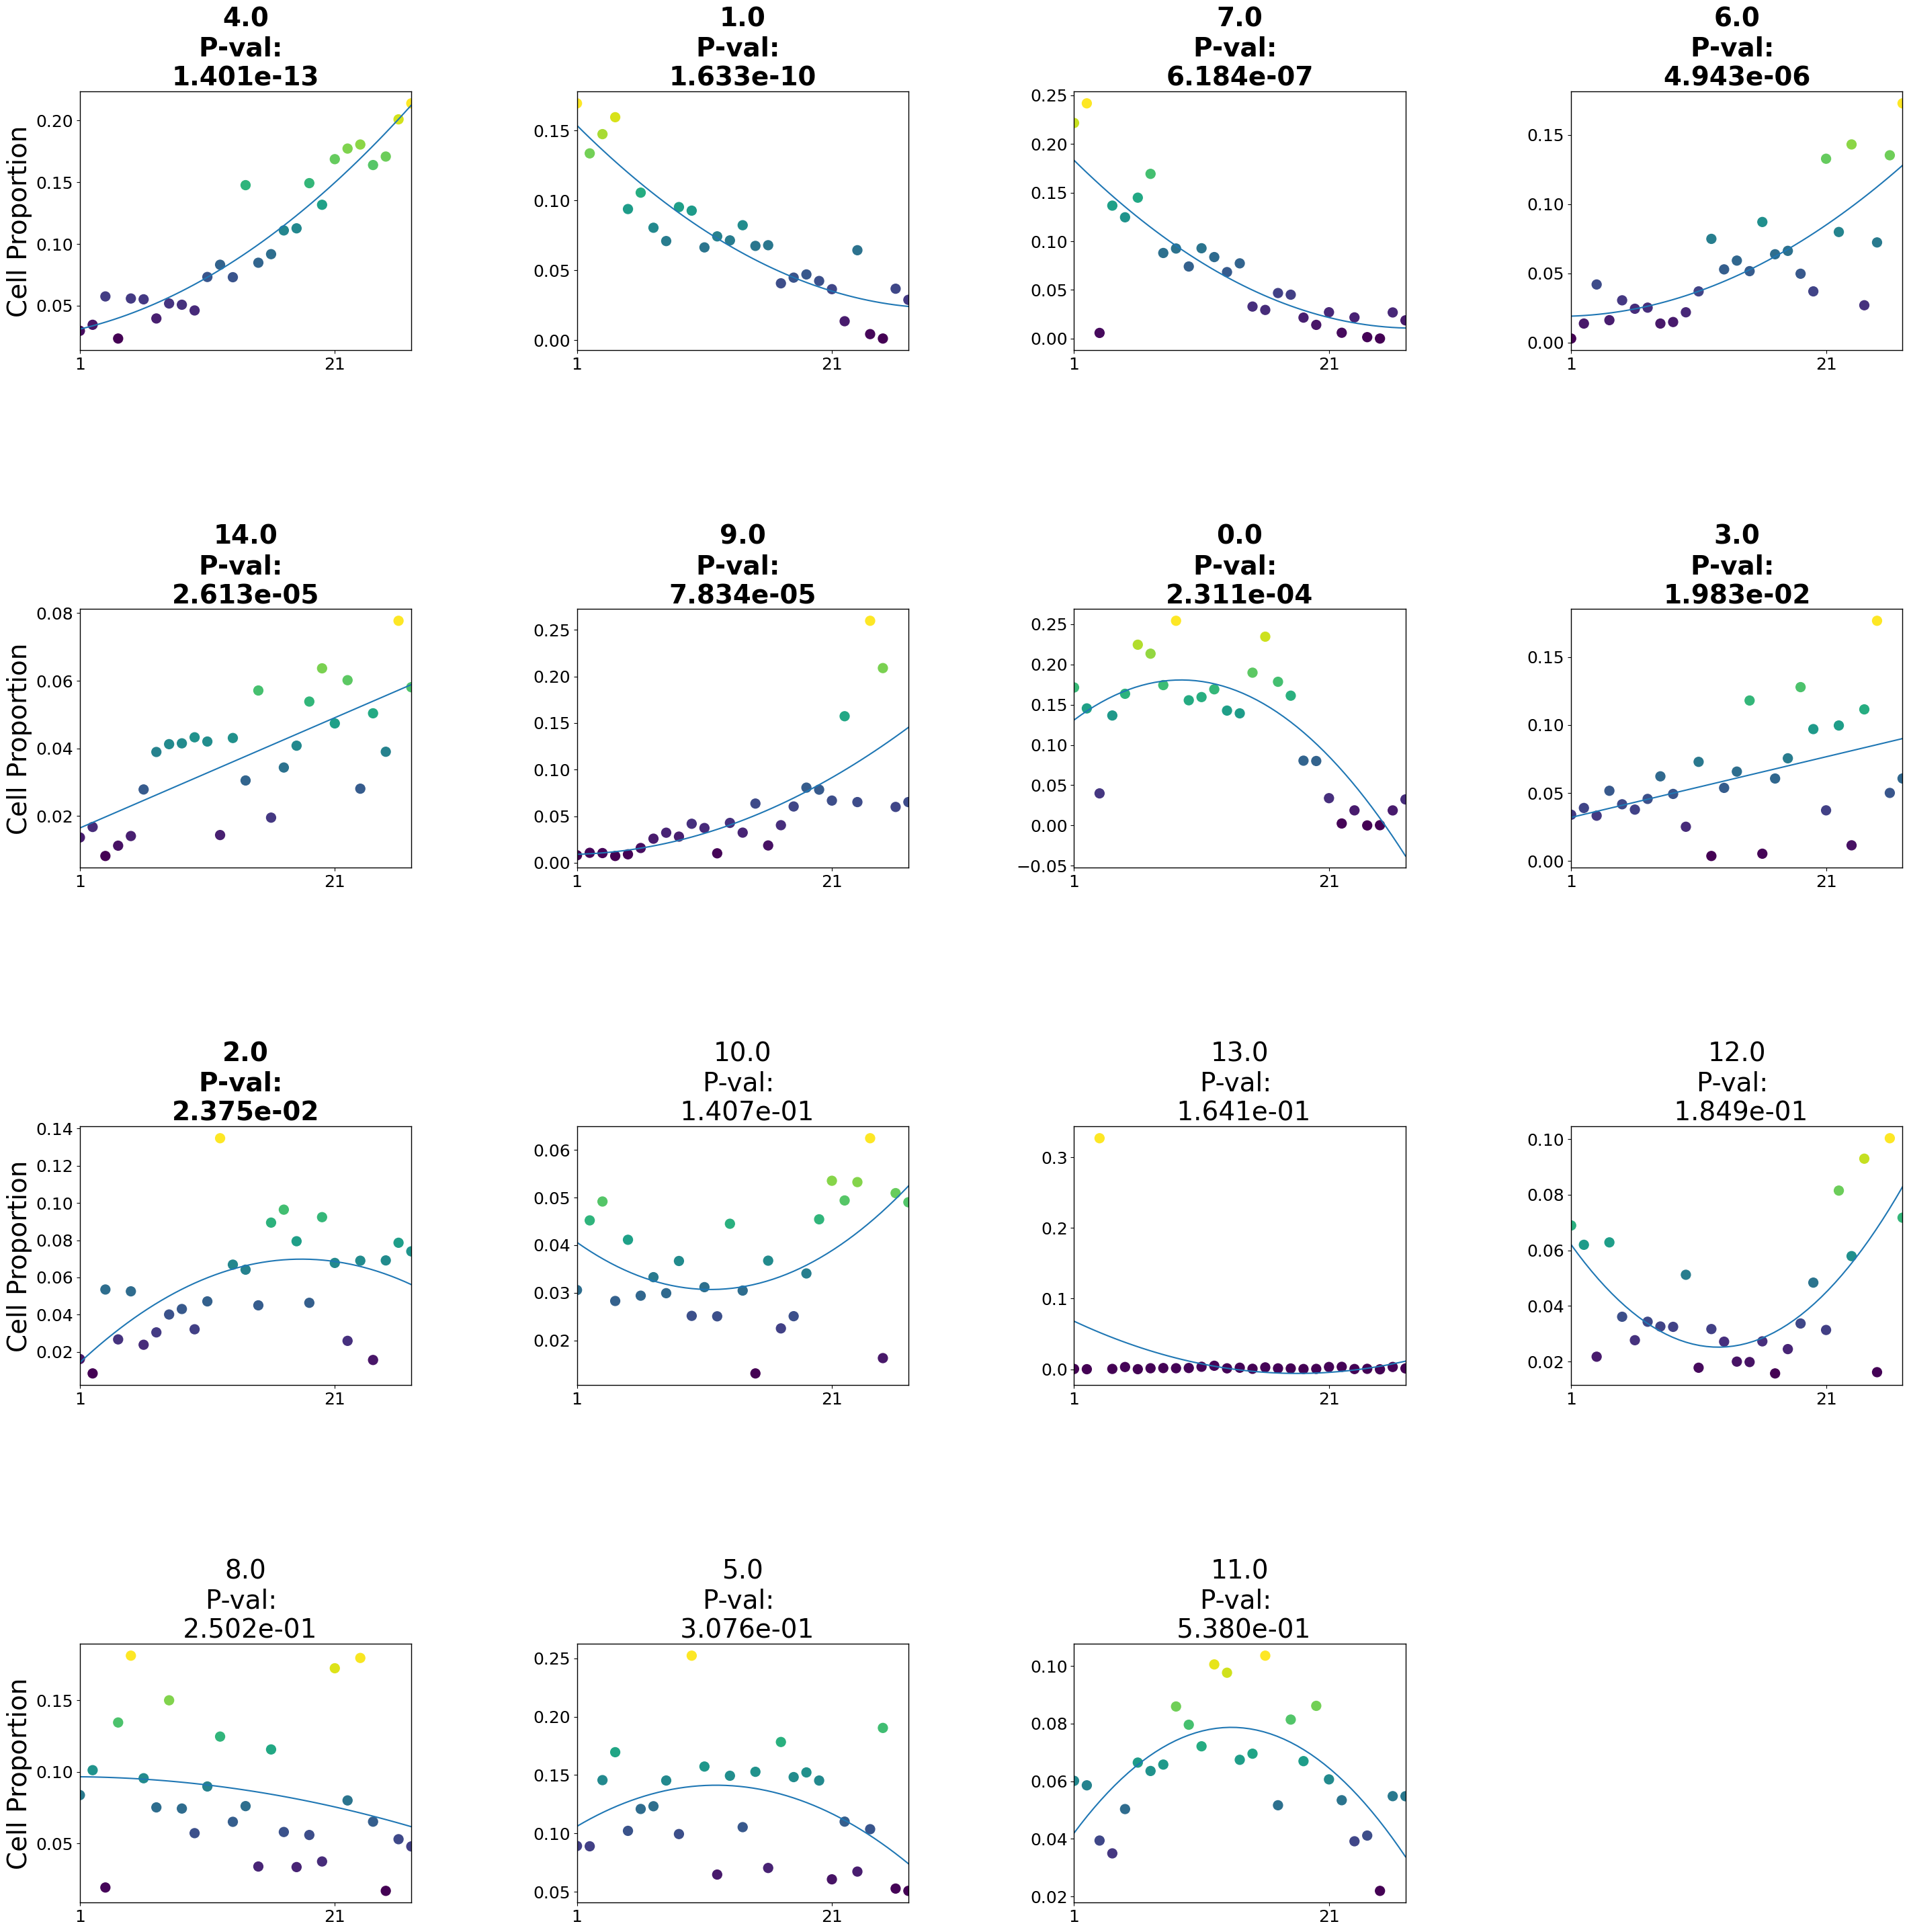

In [221]:
cell_importance(adata,height=35,width=35,fontsize=28,xlim=20,figsize=(5,5))

In [222]:
correlation_categorical_with_trajectory(adata, sample_col = 'Donor', features = ['batch','status',])

,Feature,ANOVA_FStatistic,ANOVA_PValue
0,batch,15.160269,0.000651
1,status,6.239367,0.000681
